In [7]:
import os
import json
import sys
from os.path import join
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


eval_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/results/objrel_T5_DiT_B_pilot/generalization_eval/"

In [30]:
import os
from os.path import join
model_run_name = "objrel_T5_DiT_B_pilot"
eval_dir = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/results/objrel_T5_DiT_B_pilot/generalization_eval"
prefix = "summary_across_checkpoints_templates"
files = [f for f in os.listdir(eval_dir) if f.startswith(prefix)]
print(files)

['summary_across_checkpoints_templates.csv', 'summary_across_checkpoints_templates.red_to_crimson____color1___shape1__is__r_etc.b431cfba.csv', 'summary_across_checkpoints_templates.none____color1___shape1__is__rel_text____etc.73d4861e.csv', 'summary_across_checkpoints_templates.blue_to_navy____color1___shape1__is__rel_etc.7acdbf61.csv', 'summary_across_checkpoints_templates.objrel_T5_DiT_B_pilot____color1___shape1__is__rel_text___color2___shape2____red_to_crimson_False.6436a8b9.csv']


In [13]:
summary_df_inverse = pd.read_csv(join(eval_dir, "summary_across_checkpoints_templates.none____color1___shape1__is__rel_text____etc.73d4861e.csv"))
summary_df_inverse["color_synonym_map"] = "none"
summary_df_red_to_crimson = pd.read_csv(join(eval_dir, "summary_across_checkpoints_templates.red_to_crimson____color1___shape1__is__r_etc.b431cfba.csv"))
summary_df_red_to_crimson["color_synonym_map"] = "red_to_crimson"
summary_df_blue_to_navy = pd.read_csv(join(eval_dir, "summary_across_checkpoints_templates.blue_to_navy____color1___shape1__is__rel_etc.7acdbf61.csv"))
summary_df_blue_to_navy["color_synonym_map"] = "blue_to_navy"
summary_df = pd.concat([summary_df_inverse, summary_df_red_to_crimson, summary_df_blue_to_navy])
# summary_df.to_csv(join(eval_dir, "summary_across_checkpoints_templates.all.csv"), index=False)


In [ ]:
import seaborn as sns
from circuit_toolkit.plot_utils import saveallforms

/tmp/ipykernel_2903444/103038486.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


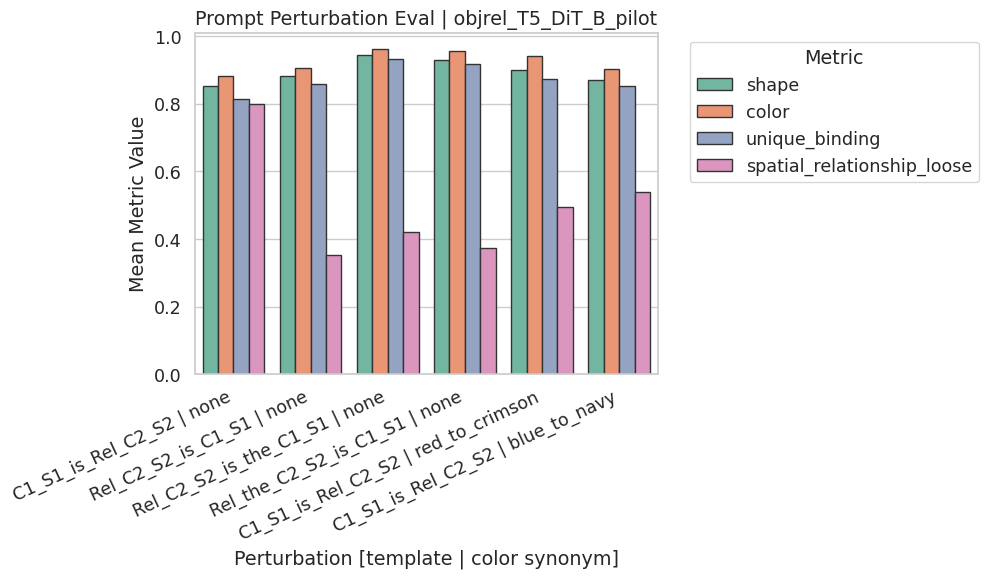

In [36]:
figdir = "/n/home12/binxuwang/Github/DiffusionObjectRelation/Figures/DiT_T5_perturbation_robustness"
metrics = ['shape', 'color', 'unique_binding', 'spatial_relationship_loose'] # 'overall', 'spatial_relationship', 'Dx', 'Dy', 
# Compute mean of each metric across color_synonym_map and template
agg_df = summary_df.groupby(['color_synonym_map', 'template'], sort=False)[metrics].mean().reset_index()

# Convert to long-form for seaborn plotting
agg_long = agg_df.melt(
    id_vars=['color_synonym_map', 'template'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Mean Value'
)

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid", font_scale=1.15)
# Bar plot: x = color_synonym_map (eval runs), hue = metric, y = mean value
# Create a new column that combines color_synonym_map and template for x-axis labeling
agg_long["EvalRun_Template"] = (
    agg_long["template"].str.replace("color", "C").str.replace("shape", "S").str.replace("rel_text", "Rel") +
    " | " +
    agg_long["color_synonym_map"]
)

# Ensure x-axis categories preserve original order of occurrence (no sorting)
evalrun_template_order = agg_long["EvalRun_Template"].drop_duplicates().tolist()

sns.barplot(
    data=agg_long,
    x="EvalRun_Template",
    y="Mean Value",
    hue="Metric",
    ci=None,
    palette="Set2",
    edgecolor="0.2",
    order=evalrun_template_order  # preserve order of occurrence
)
plt.xticks(rotation=25, horizontalalignment='right')
plt.xlabel("Perturbation [template | color synonym]")
plt.ylabel("Mean Metric Value")
plt.title(f"Prompt Perturbation Eval | {model_run_name}")
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_prompt_perturbation_eval_summary")
plt.show()

In [11]:
for i, eval_csv_name in enumerate(files):
    print(f"Processing {eval_csv_name}")
    eval_df = pd.read_csv(join(eval_dir, eval_csv_name))
    print(eval_df.head())


Processing summary_across_checkpoints_templates.csv
                  checkpoint                                         template  \
0  epoch_1000_step_40000.pth          color1_shape1_is_rel_text_color2_shape2   
1  epoch_1000_step_40000.pth      color1_shape1_is_rel_text_the_color2_shape2   
2  epoch_1000_step_40000.pth             color1_shape1_rel_text_color2_shape2   
3  epoch_1000_step_40000.pth         color1_shape1_rel_text_the_color2_shape2   
4  epoch_1000_step_40000.pth  the_color1_shape1_is_rel_text_the_color2_shape2   

    overall     shape     color  unique_binding  spatial_relationship  \
0  0.583411  0.877667  0.910714        0.848021              0.583411   
1  0.253440  0.898036  0.951685        0.880914              0.253440   
2  0.349258  0.841528  0.865028        0.805040              0.349258   
3  0.179538  0.900858  0.971127        0.887485              0.179538   
4  0.251701  0.903216  0.943491        0.880295              0.251701   

   spatial_relationshi

In [ ]:
"eval_df_all_checkpoints_all_templates"